In [1]:
import random

def choose_coin():
    rand = random.randint(0,3)
    coin_probs = [1/3,1/4,1/2,1/5]
    return coin_probs[rand] #the coin that Ali randomly chooses
selected_coin = choose_coin()
selected_coin

0.25

In [2]:
import numpy as np

test_statistic = np.random.binomial(n = 100,p = selected_coin,size = 1)[0]
print(test_statistic)

23


In [3]:
z = (test_statistic - 0.5*100)/((100*0.5*0.5)**(1/2))
z

np.float64(-5.4)

In [4]:
from scipy.stats import norm

threshold = abs(norm.ppf(0.025))
print(f'{threshold:.2f}')

1.96


In [5]:
test_res = abs(z) <= threshold
print("H0: The coin is fair \nTest result on H0:",test_res)

H0: The coin is fair 
Test result on H0: False


In [6]:
def judge(selected_coin,coin_result,test_res):
    court_res = "The true p in probability distribution of the coin Ali first chose was:" + str(selected_coin) +"\n"
    court_res = court_res + "number of heads:" + str(coin_result) + "\n"
    if test_res:
        court_res = court_res + "The judge decided Ali is not guilty!"
    else:
        court_res = court_res + "The judge decided Ali is guilty!)"
    
    return(court_res)

def court_trial(print_type, en):
    selected_coin = choose_coin()   #Ali chooses a coin
    coin_result = np.random.binomial(n = 100,p = selected_coin,size = 1)[0]   #flipping the coin 100 times
    z = (coin_result - 0.5*100)/((100*0.5*0.5)**(1/2)) #calculating z
    threshold =  abs(norm.ppf(0.025))   #finding the bounds of CI
    test_res = abs(z) <= threshold   #deciding the result

    if print_type == 1:
        full_res = categorize_res(test_res, selected_coin)
        if(en):
            print(full_res[0])
        return(full_res[1])

    elif(print_type == 2):
        print(judge(selected_coin,coin_result,test_res))
    


court_trial(2,True)

The true p in probability distribution of the coin Ali first chose was:0.25
number of heads:20
The judge decided Ali is guilty!)


In [7]:
def categorize_res(test_res, used_prob):
    res_num = 0
    res = "H0: The coin is fair \nTest result on H0:"+ str(test_res) + "\n"
    res = res + "The true p in probability distribution of the coin was:" + str(used_prob) + "\n"
    
    if(~test_res and used_prob == 0.5):
        res = res + "The test failed with Error type 1, true probability was" + str(used_prob) + "but the test results were:" + str(test_res)
        res_num = 1
    elif(test_res and used_prob!=0.5):
        res = res + "The test failed with Error type 2, true probability was" + str(used_prob) + "but the test results were:" + str(test_res)
        res_num = 2
      
    else:
        res = res+"The test did a great job!"
        if(~test_res):
            res_num = -1
    return([res,res_num])

court_trial(1,True)

H0: The coin is fair 
Test result on H0:False
The true p in probability distribution of the coin was:0.3333333333333333
The test did a great job!


-1

In [8]:
def rep():
    err_one = 0
    err_two = 0
    right_true = 0
    right_false = 0
    for i in range(1000):
        result = court_trial(1,False)
        if(result == -1):
            right_false = right_false + 1
        elif(result == 0):
            right_true = right_true + 1
        elif(result == 1):
            err_one = err_one + 1
        else:
            err_two = err_two + 1
     
    alpha =  err_one/(err_one+right_true)
    beta = err_two/(err_two+right_false)
    power = right_false/(err_two+right_false)
    if(right_true+err_two > right_false + err_one):
        r = "Ali is not guilty"
    else:
        r = "Ali is guilty"
    
    return([r,alpha,beta,power])


rep_res = rep()
print(rep_res[0])

Ali is guilty


In [9]:
print("alpha estimator (percentage of error 1 in this test): "+ str(rep_res[1]) + "\n beta estimator (percentage of error 2 in this test): " + str(rep_res[2]) + 
    "\n power estimator: " + str(rep_res[3]))

alpha estimator (percentage of error 1 in this test): 0.05138339920948617
 beta estimator (percentage of error 2 in this test): 0.024096385542168676
 power estimator: 0.9759036144578314


Text(0.5, 0, 'Index')

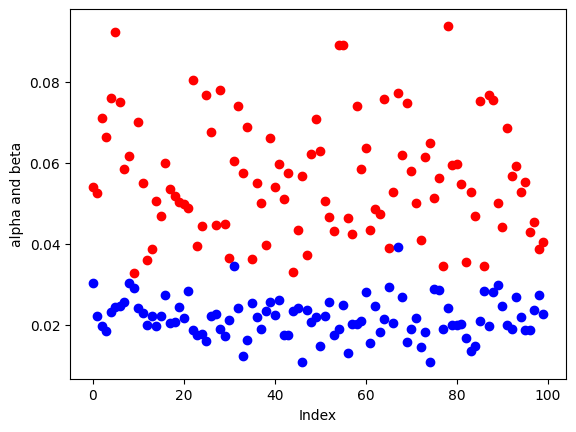

In [10]:
import matplotlib.pyplot as plt

alphas = np.array([])
betas = np.array([])
for i in range(100):
    res = rep()
    alphas = np.append(alphas,res[1])
    betas = np.append(betas,res[2])


plt.scatter(list(range(len(alphas))),alphas,color = "r")
plt.scatter(list(range(len(betas))),betas,color = "b")
plt.ylabel("alpha and beta")
plt.xlabel("Index")